# Exercise 6: Visualization


* Produce the plot shown below in Julia. You may use the Plots or the Makie Package.
* Submit your project following the submission guidelines
* Be sure that you include the code and the figure(s)


In [4]:
import Pkg
# Pkg.add(["Graphs", "Colors", "Plots"])

using Images
using Plots
using Random
using Graphs

Pkg.offline(true)

# Código en Julia

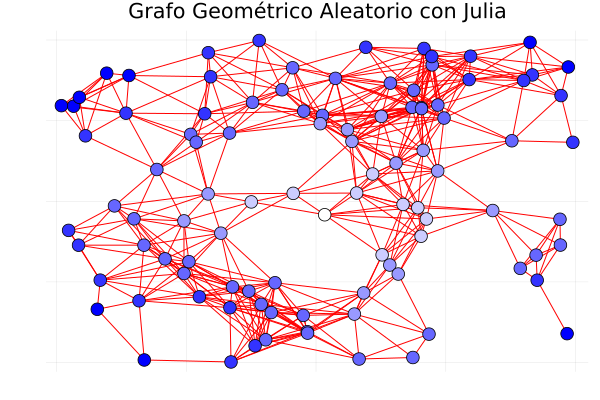

In [6]:

n_nodes = 100 # Número de nodos
r=2 #Distancia max para aristas
zg=10 #Tamaño del plano

cg=zg/2 #Punto central del plano
# Generando posiciones aleatorias para los nodos
x_positions = rand(n_nodes)*zg
y_positions = rand(n_nodes)*zg
g = SimpleGraph(n_nodes) #Grafica simple para calcular shortest paths
connections = Set{Tuple{Int, Int}}()


#Inicializando búsqueda nodo central
dmin=zg
n_center=0

for i in 1:n_nodes
    #Generando aristas
    for j in i+1:n_nodes
        d=sqrt((x_positions[i]-x_positions[j])^ 2+(y_positions[i]-y_positions[j])^ 2)
        if d < r
            push!(connections, (i, j))  
            add_edge!(g, i, j)  
        end
    end

    #Encontrando el nodo más al centro
    dc=sqrt((x_positions[i]-cg)^ 2+(y_positions[i]-cg)^ 2)
    if dc < dmin
        dmin=dc
        n_center=i
    end
end

#Calculando caminos más cortos de nodo central a cada nodo
distances = dijkstra_shortest_paths(g, n_center).dists

#Normalizando distancias
max_distance_value = maximum(distances)
normalized_distances = distances / max_distance_value


# colors = [RGB(0 + d, 0 + d, 1.0) for d in normalized_distances]
colors = [RGB(1 - d, 1 - d, 1.0) for d in normalized_distances]

# Dibujando aristas
plot()
for (i, j) in connections
    plot!([x_positions[i], x_positions[j]], [y_positions[i], y_positions[j]], seriestype = :line, color = :red,label=false
            ,axis=false
            )
end

# Dibujando los nodos
scatter!(x_positions, y_positions, color=colors, markersize = 7,label=false, title="Grafo Geométrico Aleatorio con Julia")

namefig="./fig/6.Visualization.png"
savefig(namefig)
img = Images.load(namefig)
display(img)